# Special ensembles on strong-signal, severely imbalanced datasets

Notebook 05 showed the special (resampling) ensembles do not beat the standard
ensembles on **hard** datasets -- but those datasets are hard because the
features overlap the classes, which is the regime *least* favourable to
resampling (resampling rebalances classes, it cannot create signal).

This notebook tests the opposite, most-favourable regime: datasets where a
standard ensemble already discriminates the classes well (ROC-AUC > 0.9) but the
positive class is **rare**, including a tiny absolute minority (credit-card fraud
is 0.17% positive, ~345 training cases). If resampling ever helps, it should
help here. Everything else is identical to notebooks 02 and 05: same models,
same successive-halving tuning, same optimal-threshold evaluation. See
`docs/imbalanced_datasets.md` for provenance and licenses.


In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
import pickle
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from functions.imbalanced_data import DATASETS_IMBALANCED, load_imbalanced_dataset
from functions.analysis import create_df
from functions.plotting import compute_ylim

warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)
datasets = DATASETS_IMBALANCED
datasets

['htru2', 'creditcard']

## Load results

In [3]:
with open('../models/ensembles-imbalanced/results', 'rb') as f:
    classic_dict = pickle.load(f)

with open('../models/special-ensembles-imbalanced/results', 'rb') as f:
    special_dict = pickle.load(f)

scores_dict = {
    key: {**classic_dict[key], **special_dict[key]}
    for key in classic_dict
}

In [4]:
standard_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']
special_models = ['rusboost', 'easyEnsemble', 'balancedRF']
models = standard_models + special_models

## Strong signal, severe imbalance

Unlike the hard datasets, here the best standard ensemble reaches a high
ROC-AUC: the signal is there. What makes these difficult is the rarity of the
positive class -- in particular the small *absolute* number of positive training
examples. This is the situation in which undersampling/resampling is usually
argued to help.

In [5]:
rows = []
for ds in datasets:
    X_train, X_test, y_train, y_test = load_imbalanced_dataset(ds)
    uni = max(
        max(roc_auc_score(y_train, X_train.iloc[:, j]),
            1 - roc_auc_score(y_train, X_train.iloc[:, j]))
        for j in range(X_train.shape[1])
    )
    best_std = max(scores_dict[ds][m][0] for m in standard_models)  # roc is column 0
    rows.append({
        'dataset': ds,
        'positive_rate': round(float(y_train.mean()), 4),
        'n_positive_train': int(y_train.sum()),
        'max_univariate_auc': round(float(uni), 3),
        'best_standard_roc': round(float(best_std), 3),
    })
signal = pd.DataFrame(rows).set_index('dataset')
signal

,positive_rate,n_positive_train,max_univariate_auc,best_standard_roc
dataset,,,,
htru2,0.0954,1195,0.973,0.979
creditcard,0.0234,336,0.950,0.983


In [6]:
# sanity check: one full metrics table
create_df(scores_dict, datasets[0], models)

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.975950,0.006487,0.925760,0.011367,0.931093,0.013116,0.871563,0.020996,0.900019,0.005331,0.891981,0.004815,0.951633,0.003860,0.014885,0.000557,0.951274,0.003851,0.469643,0.101987
ada,0.976055,0.003916,0.914364,0.012717,0.910713,0.018433,0.874523,0.016882,0.891925,0.004616,0.882686,0.004920,0.947815,0.003623,0.131009,0.000758,0.947499,0.003736,0.480949,0.006996
gbm,0.979190,0.005084,0.926928,0.011477,0.908636,0.017962,0.878332,0.011305,0.893039,0.007362,0.884175,0.007481,0.949075,0.003855,0.017213,0.001338,0.948866,0.004033,0.272254,0.272197
cat,0.974489,0.005279,0.917470,0.008102,0.924159,0.021603,0.847622,0.026347,0.883622,0.007289,0.875146,0.007530,0.942985,0.002465,0.016966,0.000917,0.942396,0.002237,0.614879,0.139818
lgbm,0.972672,0.005391,0.917869,0.008510,0.919733,0.014065,0.856891,0.012832,0.887104,0.009787,0.878004,0.010449,0.944010,0.004133,0.016893,0.001244,0.943547,0.004244,0.578423,0.160339
xgb,0.976745,0.005060,0.924473,0.009883,0.920039,0.012998,0.875568,0.011330,0.897098,0.002939,0.888359,0.003059,0.950743,0.003297,0.015268,0.000456,0.950339,0.003455,0.469492,0.080492
rusboost,0.978581,0.005785,0.917021,0.016559,0.932540,0.016182,0.863010,0.018890,0.896095,0.004454,0.887978,0.004152,0.952600,0.001867,0.047926,0.001302,0.952345,0.002058,0.832778,0.028041
easyEnsemble,0.973467,0.005563,0.904044,0.013730,0.906823,0.010344,0.870181,0.016679,0.887962,0.007335,0.878276,0.007600,0.939733,0.004660,0.097990,0.001200,0.939005,0.004428,0.702976,0.038979
balancedRF,0.976580,0.006313,0.924386,0.013878,0.920922,0.019339,0.865994,0.016856,0.892290,0.005703,0.883460,0.006291,0.953414,0.002175,0.031344,0.001436,0.953113,0.002164,0.870869,0.055736


## Predicted probability distributions

Check the special ensembles produce well-spread probabilities (a degenerate,
near-constant distribution would make any threshold-based metric meaningless).

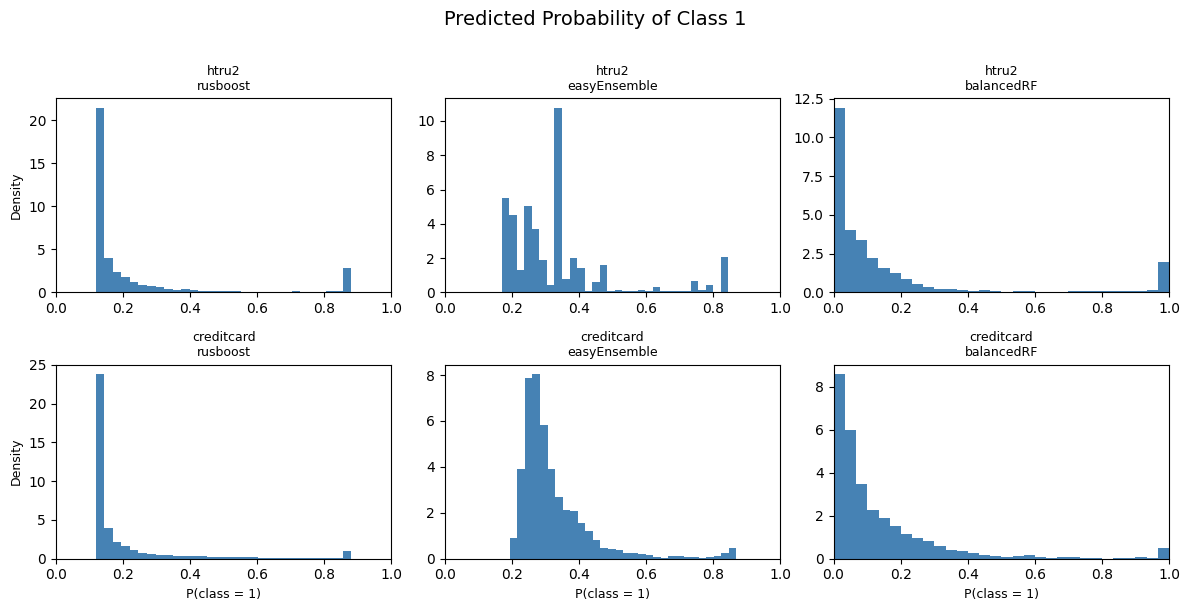

In [7]:
fig, axes = plt.subplots(len(datasets), len(special_models),
                         figsize=(4 * len(special_models), 3 * len(datasets)))
MODELS_DIR = '../models/special-ensembles-imbalanced'
for i, dataset in enumerate(datasets):
    _, X_test, _, y_test = load_imbalanced_dataset(dataset)
    for j, estimator in enumerate(special_models):
        search = joblib.load(f'{MODELS_DIR}/{dataset}_{estimator}.pkl')
        probs = search.predict_proba(X_test)[:, 1]
        ax = axes[i, j]
        ax.hist(probs, bins=30, density=True, color='steelblue')
        ax.set_xlim(0, 1)
        ax.set_title(f'{dataset}\n{estimator}', fontsize=9)
        if j == 0:
            ax.set_ylabel('Density', fontsize=9)
        if i == len(datasets) - 1:
            ax.set_xlabel('P(class = 1)', fontsize=9)
plt.suptitle('Predicted Probability of Class 1', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/special-ensembles-imbalanced_prob_dist.png', dpi=200, bbox_inches='tight')
plt.show()

## Performance per metric

Each panel is one dataset; points are the nine models (mean +/- std over the
bootstrap test samples). The pink band is the random forest's error bar. A
special ensemble 'wins' only if it sits clearly **above** the standard ensembles.
All threshold-based metrics are taken at their optimal threshold.

In [8]:
def plot_metric(metric, std_metric, title, fname):
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, data in zip(axes, datasets):
        df = create_df(scores_dict, data, models)
        means = df[metric]
        stds = df[std_metric]
        upper = df.loc['rf', metric] + df.loc['rf', std_metric]
        lower = df.loc['rf', metric] - df.loc['rf', std_metric]
        colors = ['tab:blue'] * len(standard_models) + ['tab:red'] * len(special_models)
        ax.errorbar(x=df.index, y=means, yerr=stds, fmt='none', ecolor='gray', capsize=5, zorder=1)
        ax.scatter(df.index, means, c=colors, s=80, zorder=2)
        ax.set_title(data, fontsize=14)
        ax.set_ylim(compute_ylim(means, stds, upper, lower))
        ax.tick_params(axis='x', rotation=90)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)
    plt.suptitle(title, fontsize=15, y=1.03)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

# blue = standard ensembles, red = special (resampling) ensembles; pink band = RF +/- std

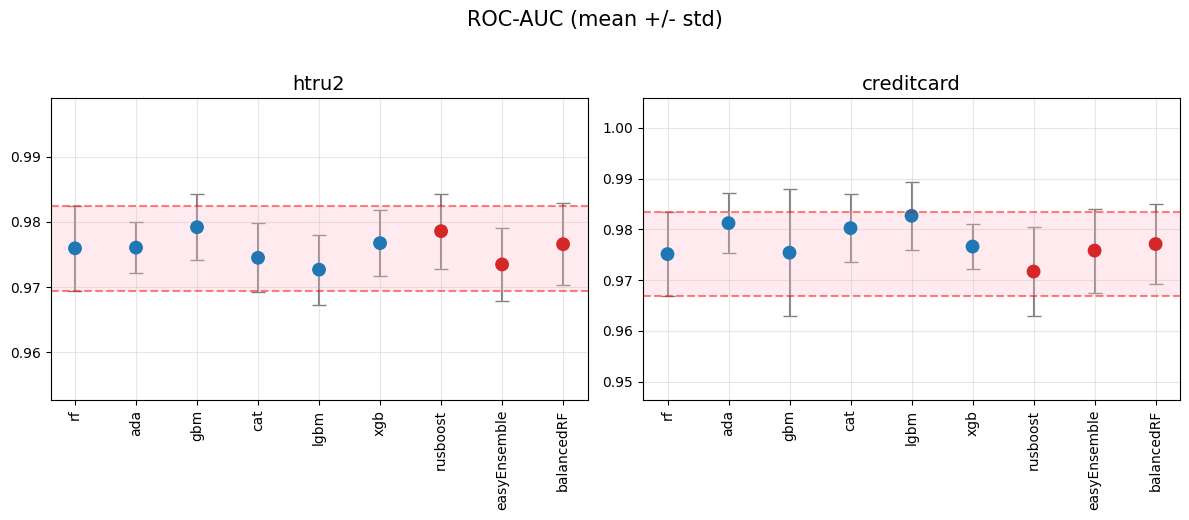

In [9]:
plot_metric('roc', 'roc_std', 'ROC-AUC (mean +/- std)', '../figures/special-ensembles-imbalanced_rocauc.png')

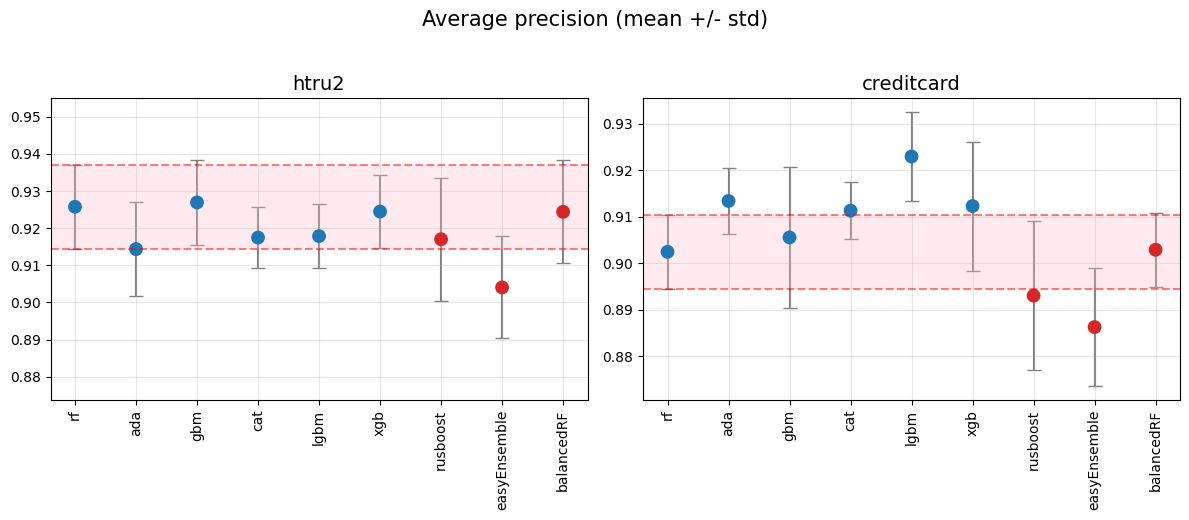

In [10]:
plot_metric('ap', 'ap_std', 'Average precision (mean +/- std)', '../figures/special-ensembles-imbalanced_ap.png')

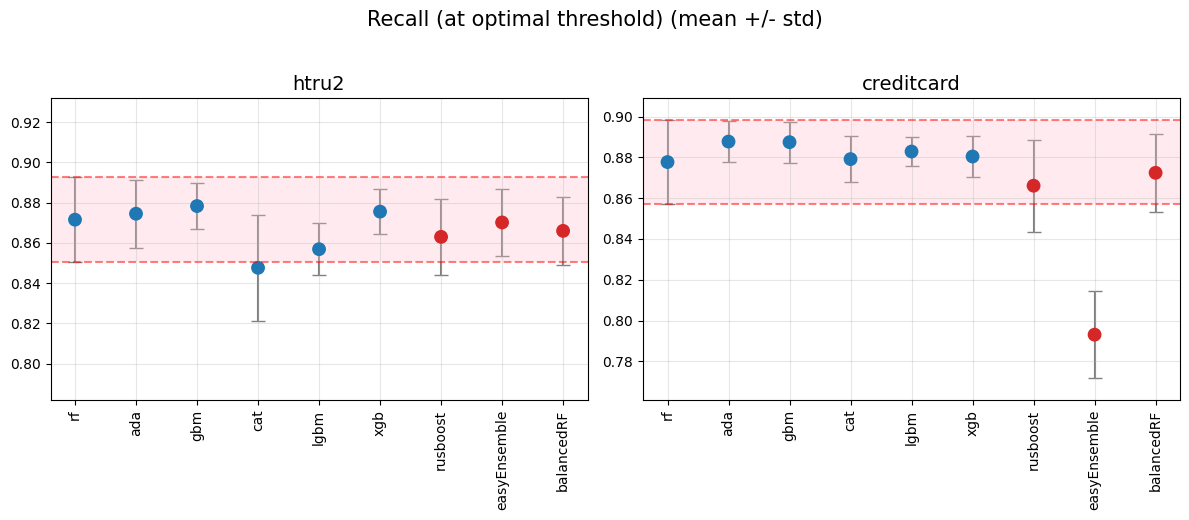

In [11]:
plot_metric('recall', 'recall_std', 'Recall (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-imbalanced_recall.png')

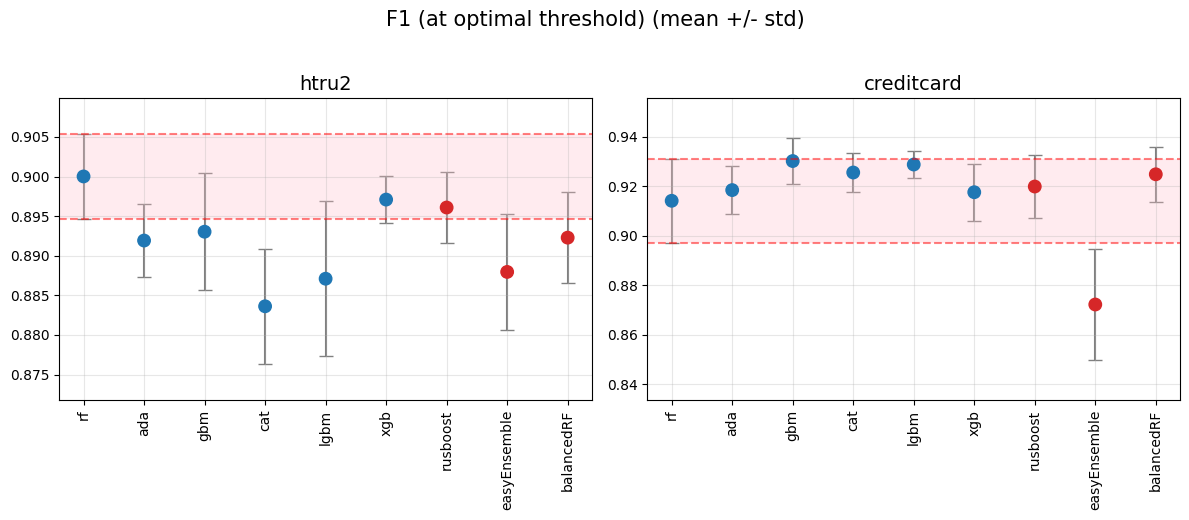

In [12]:
plot_metric('f1_score', 'f1_std', 'F1 (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-imbalanced_f1.png')

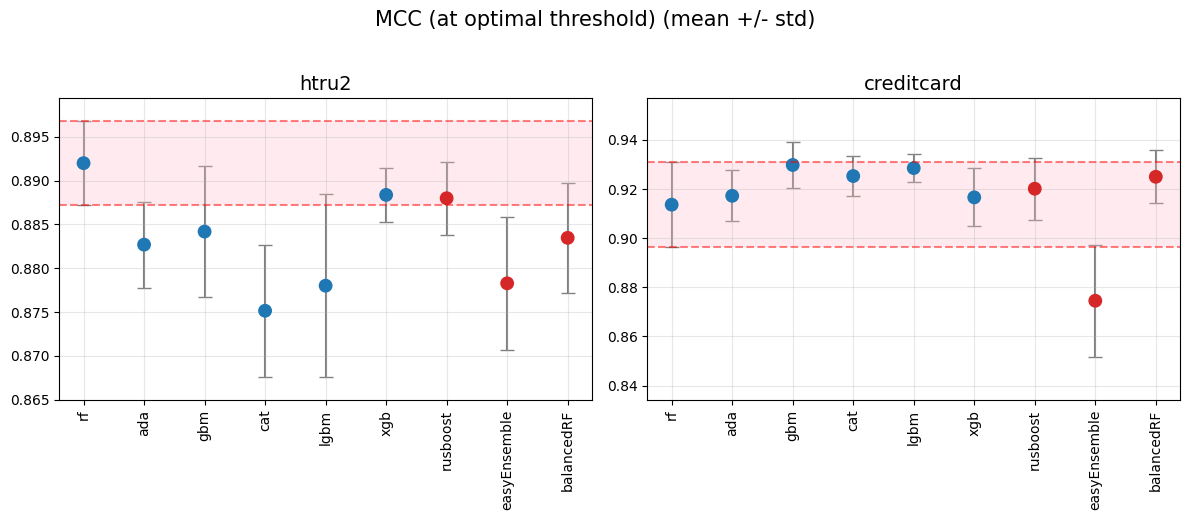

In [13]:
plot_metric('mcc', 'mcc_std', 'MCC (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-imbalanced_mcc.png')

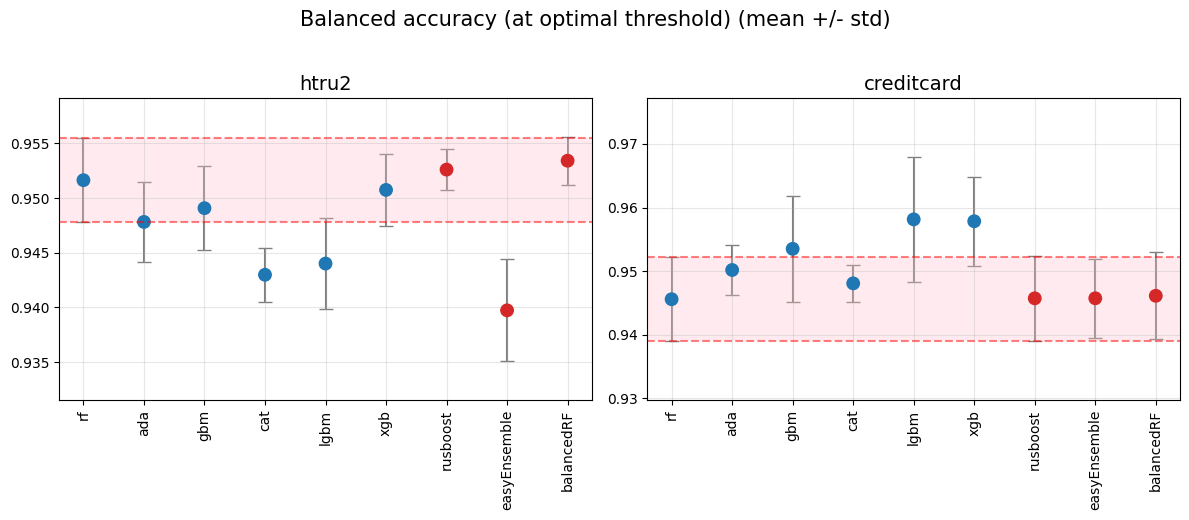

In [14]:
plot_metric('ba', 'ba_std', 'Balanced accuracy (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-imbalanced_ba.png')

## Combined table

In [15]:
dfs = [create_df(scores_dict, data, models) for data in datasets]
result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
for col, std in [('roc', 'roc_std'), ('ap', 'ap_std'), ('f1_score', 'f1_std'),
                 ('mcc', 'mcc_std'), ('ba', 'ba_std'), ('gmean', 'gmean_std')]:
    result[f'{col}_pm'] = (result[col].round(3).astype(str) + ' +/- '
                            + result[std].round(3).astype(str))
result.to_csv('../results/special-ensembles-imbalanced_models_performance.csv')
result[['roc_pm', 'ap_pm', 'f1_score_pm', 'mcc_pm', 'ba_pm', 'gmean_pm']]

roc_pm            ap_pm      f1_score_pm  \
dataset    model                                                             
htru2      rf            0.976 +/- 0.006  0.926 +/- 0.011    0.9 +/- 0.005   
           ada           0.976 +/- 0.004  0.914 +/- 0.013  0.892 +/- 0.005   
           gbm           0.979 +/- 0.005  0.927 +/- 0.011  0.893 +/- 0.007   
           cat           0.974 +/- 0.005  0.917 +/- 0.008  0.884 +/- 0.007   
           lgbm          0.973 +/- 0.005  0.918 +/- 0.009   0.887 +/- 0.01   
           xgb           0.977 +/- 0.005   0.924 +/- 0.01  0.897 +/- 0.003   
           rusboost      0.979 +/- 0.006  0.917 +/- 0.017  0.896 +/- 0.004   
           easyEnsemble  0.973 +/- 0.006  0.904 +/- 0.014  0.888 +/- 0.007   
           balancedRF    0.977 +/- 0.006  0.924 +/- 0.014  0.892 +/- 0.006   
creditcard rf            0.975 +/- 0.008  0.902 +/- 0.008  0.914 +/- 0.017   
           ada           0.981 +/- 0.006  0.913 +/- 0.007   0.919 +/- 0.01   
           gbm           0.975 +/- 0.012  0.906 +/- 0.015   0.93 +/- 0.009   
           cat            0.98 +/- 0.007  0.911 +/- 0.006  0.926 +/- 0.008   
           lgbm          0.983 +/- 0.007   0.923 +/- 0.01  0.929 +/- 0.006   
           xgb           0.977 +/- 0.004  0.912 +/- 0.014  0.918 +/- 0.011   
           rusboost      0.972 +/- 0.009  0.893 +/- 0.016   0.92 +/- 0.013   
           easyEnsemble  0.976 +/- 0.008  0.886 +/- 0.013  0.872 +/- 0.022   
           balancedRF    0.977 +/- 0.008  0.903 +/- 0.008  0.925 +/- 0.011   

                                  mcc_pm            ba_pm         gmean_pm  
dataset    model                                                            
htru2      rf            0.892 +/- 0.005  0.952 +/- 0.004  0.951 +/- 0.004  
           ada           0.883 +/- 0.005  0.948 +/- 0.004  0.947 +/- 0.004  
           gbm           0.884 +/- 0.007  0.949 +/- 0.004  0.949 +/- 0.004  
           cat           0.875 +/- 0.008  0.943 +/- 0.002  0.942 +/- 0.002  
           lgbm           0.878 +/- 0.01  0.944 +/- 0.004  0.944 +/- 0.004  
           xgb           0.888 +/- 0.003  0.951 +/- 0.003   0.95 +/- 0.003  
           rusboost      0.888 +/- 0.004  0.953 +/- 0.002  0.952 +/- 0.002  
           easyEnsemble  0.878 +/- 0.008   0.94 +/- 0.005  0.939 +/- 0.004  
           balancedRF    0.883 +/- 0.006  0.953 +/- 0.002  0.953 +/- 0.002  
creditcard rf            0.914 +/- 0.017  0.946 +/- 0.007  0.945 +/- 0.007  
           ada            0.917 +/- 0.01   0.95 +/- 0.004   0.95 +/- 0.004  
           gbm             0.93 +/- 0.01  0.954 +/- 0.008  0.953 +/- 0.008  
           cat           0.925 +/- 0.008  0.948 +/- 0.003  0.948 +/- 0.003  
           lgbm          0.929 +/- 0.006   0.958 +/- 0.01   0.958 +/- 0.01  
           xgb           0.917 +/- 0.012  0.958 +/- 0.007  0.957 +/- 0.007  
           rusboost       0.92 +/- 0.013  0.946 +/- 0.007  0.945 +/- 0.007  
           easyEnsemble  0.875 +/- 0.023  0.946 +/- 0.006  0.946 +/- 0.006  
           balancedRF    0.925 +/- 0.011  0.946 +/- 0.007  0.945 +/- 0.007

## Do special ensembles win where imbalance is severe?

For each dataset and metric, compare the **best** special ensemble against the
**best** standard ensemble. A positive delta means resampling helped.

In [16]:
metric_cols = {'roc': 'roc', 'ap': 'ap', 'f1': 'f1_score', 'mcc': 'mcc',
               'ba': 'ba', 'gmean': 'gmean'}
summary = []
for ds in datasets:
    df = create_df(scores_dict, ds, models)
    for short, col in metric_cols.items():
        best_std = df.loc[standard_models, col].max()
        best_spc = df.loc[special_models, col].max()
        summary.append({
            'dataset': ds, 'metric': short,
            'best_standard': round(float(best_std), 3),
            'std_model': df.loc[standard_models, col].idxmax(),
            'best_special': round(float(best_spc), 3),
            'special_model': df.loc[special_models, col].idxmax(),
            'delta_special_minus_standard': round(float(best_spc - best_std), 3),
        })
summary = pd.DataFrame(summary)
summary

,dataset,metric,best_standard,std_model,best_special,special_model,delta_special_minus_standard
0,htru2,roc,0.979,gbm,0.979,rusboost,-0.001
1,htru2,ap,0.927,gbm,0.924,balancedRF,-0.003
2,htru2,f1,0.900,rf,0.896,rusboost,-0.004
3,htru2,mcc,0.892,rf,0.888,rusboost,-0.004
4,htru2,ba,0.952,rf,0.953,balancedRF,0.002
5,htru2,gmean,0.951,rf,0.953,balancedRF,0.002
6,creditcard,roc,0.983,lgbm,0.977,balancedRF,-0.006
7,creditcard,ap,0.923,lgbm,0.903,balancedRF,-0.020
8,creditcard,f1,0.930,gbm,0.925,balancedRF,-0.005
9,creditcard,mcc,0.930,gbm,0.925,balancedRF,-0.005


In [17]:
wins = (summary['delta_special_minus_standard'] > 0).sum()
total = len(summary)
print(f'Special ensemble beats best standard ensemble in {wins}/{total} (dataset, metric) cells')
print(f'Mean delta (best special - best standard): {summary.delta_special_minus_standard.mean():+.3f}')
print()
pivot = summary.pivot(index='dataset', columns='metric', values='delta_special_minus_standard')
pivot = pivot[['roc', 'ap', 'f1', 'mcc', 'ba', 'gmean']]
print('Delta (best special - best standard) per dataset and metric:')
pivot

Special ensemble beats best standard ensemble in 2/12 (dataset, metric) cells
Mean delta (best special - best standard): -0.006

Delta (best special - best standard) per dataset and metric:


metric,roc,ap,f1,mcc,ba,gmean
dataset,,,,,,
creditcard,-0.006,-0.020,-0.005,-0.005,-0.012,-0.012
htru2,-0.001,-0.003,-0.004,-0.004,0.002,0.002


## Conclusion

**Even in the regime most favourable to resampling, the special ensembles still
do not beat the standard ensembles.** These two datasets have strong signal
(standard ensembles reach ROC-AUC ~0.98) but severe imbalance -- htru2 ~9%
positive, creditcard ~2.4% with only ~340 fraud cases in training. Across the
two datasets and six metrics, the best special ensemble beats the best standard
ensemble in only 2 of 12 comparisons, both by +0.002 (within the bootstrap
noise); the mean gap is -0.006 in favour of the standard ensembles.

- On **htru2** the two families are tied (differences within ~0.004 on every
  metric).
- On **creditcard** the standard ensembles are ahead (average precision 0.923
  vs 0.903, MCC 0.930 vs 0.925); GBM and LightGBM are the strongest.
- **BalancedRandomForest** is again the most competitive special ensemble;
  **EasyEnsemble** is the weakest (creditcard MCC 0.875 vs 0.930).

This closes the main caveat of notebook 05. There, the datasets were hard
because the features overlap, so resampling had no signal to exploit. Here the
signal is strong and the imbalance is severe -- the textbook case for
resampling -- and it still adds nothing once metrics are read at the optimal
threshold. Combined with notebook 05, the special ensembles beat the best
standard ensemble in just 2 of 30 dataset-metric comparisons across both
regimes, both by a margin within noise.
